# Kernel / Bayesian system identification — and the Bayesian-TIB fusion

A didactic, from-scratch look at **kernel-based (Bayesian) impulse-response estimation**, and how it relates to the TIB model. See `wiki/concepts/PyMORDataDrivenID.md`.

**Part 1 — the canonical method.** Estimate the impulse response `g` as a Gaussian process with a *stability* kernel; tune the regularisation by marginal likelihood; compare to plain least squares at low SNR (with posterior uncertainty bands).

**Part 2 — Bayesian-TIB.** Use the TIB basis (poles + null vectors → mode impulse responses) as the feature map, and contrast plain TIB least-squares (`fit_output_matrix`-style) with a kernel-regularised fit on an *overcomplete* pole grid.

Everything is SISO here for clarity (the IR is a 1-D sequence we can plot).

In [1]:
%matplotlib inline
import sys, os
try:
    import ga  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, cho_factor, cho_solve
from scipy.optimize import minimize

from ga.filters.tib import poles_chebyshev_roots

rng = np.random.default_rng(0)

## A true system and noisy, low-SNR data

The true impulse response is a sum of stable decaying modes. We excite it with a white-noise input and observe the output with heavy measurement noise (**SNR = 1**, i.e. signal power = noise power).

N=400 samples, n=60 taps, SNR=1.0  (sigma=1.753)


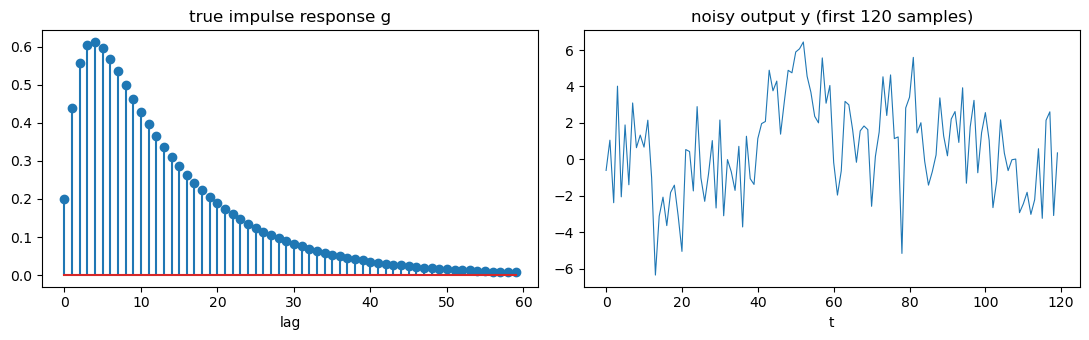

In [2]:
n = 60                                   # IR length (taps)
t = np.arange(n)
g_true = 1.0 * 0.92**t - 0.8 * 0.60**t   # two decaying modes -> a shaped IR

N = 400                                  # number of output samples
u = rng.standard_normal(N)               # white-noise excitation
Phi = toeplitz(u, np.zeros(n))           # N x n: Phi[i,k] = u[i-k] (lower-tri Toeplitz)

y_clean = Phi @ g_true
SNR = 1.0                                # low signal-to-noise (0 dB)
sigma = np.sqrt(np.var(y_clean) / SNR)
y = y_clean + sigma * rng.standard_normal(N)

relerr = lambda gh: float(np.linalg.norm(gh - g_true) / np.linalg.norm(g_true))
print(f"N={N} samples, n={n} taps, SNR={SNR}  (sigma={sigma:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].stem(t, g_true); ax[0].set_title("true impulse response g"); ax[0].set_xlabel("lag")
ax[1].plot(y[:120], lw=0.8); ax[1].set_title("noisy output y (first 120 samples)"); ax[1].set_xlabel("t")
fig.tight_layout(); plt.show()

## Baseline: plain least-squares FIR estimate

Estimate the `n` IR taps by ordinary least squares, `min_g ||y - \Phi g||^2`. With low SNR this is high-variance — it fits the noise.

plain LS rel err: 0.418


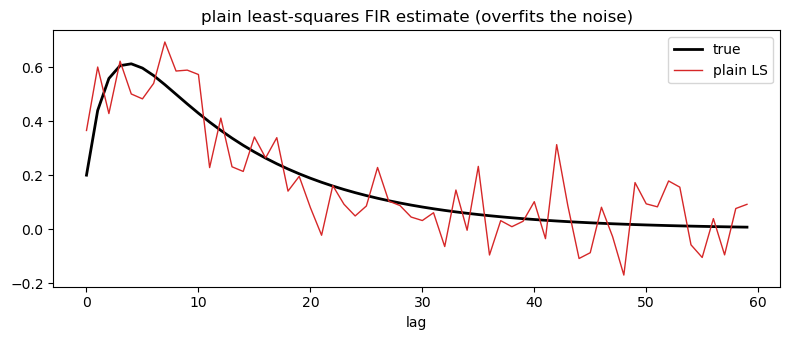

In [3]:
g_ls, *_ = np.linalg.lstsq(Phi, y, rcond=None)
print(f"plain LS rel err: {relerr(g_ls):.3f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t, g_true, "k", lw=2, label="true")
ax.plot(t, g_ls, "C3", lw=1, label="plain LS")
ax.set_title("plain least-squares FIR estimate (overfits the noise)")
ax.set_xlabel("lag"); ax.legend(); fig.tight_layout(); plt.show()

## The kernel / Bayesian estimator

Treat the impulse response as a zero-mean Gaussian process, $g \sim \mathcal{N}(0,\lambda K)$, observed through $y=\Phi g+e,\ e\sim\mathcal{N}(0,\sigma^2 I)$. The **TC (tuned-correlated / stable-spline) kernel** $K_{ij}=\alpha^{\max(i,j)}$ encodes *stable, decaying* impulse responses.

Posterior mean (the estimate) and covariance:
$$\hat g=\lambda K\Phi^\top\Sigma_y^{-1}y,\qquad \mathrm{cov}(g\mid y)=\lambda K-\lambda K\Phi^\top\Sigma_y^{-1}\Phi\,\lambda K,\qquad \Sigma_y=\lambda\,\Phi K\Phi^\top+\sigma^2 I .$$

The hyperparameters $\theta=(\alpha,\lambda,\sigma^2)$ are **not** guessed — they maximise the **marginal likelihood** (empirical Bayes):
$$-\log p(y\mid\theta)=\tfrac12\,y^\top\Sigma_y^{-1}y+\tfrac12\log\det\Sigma_y+\tfrac N2\log 2\pi .$$
So the regularisation tunes itself from the data — the reason this dominates at low SNR.

In [4]:
def tc_kernel(n, alpha):
    idx = np.arange(n)
    return alpha ** np.maximum.outer(idx, idx)        # K_ij = alpha**max(i,j)

def neg_log_marglik(theta, Phi, y):
    alpha = 1.0 / (1.0 + np.exp(-theta[0]))           # -> (0,1)
    lam, s2 = np.exp(theta[1]), np.exp(theta[2])      # -> (0, inf)
    K = tc_kernel(Phi.shape[1], alpha)
    Sig = lam * (Phi @ K @ Phi.T) + s2 * np.eye(Phi.shape[0])
    L, low = cho_factor(Sig, lower=True)
    ay = cho_solve((L, low), y)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return 0.5 * (y @ ay) + 0.5 * logdet + 0.5 * len(y) * np.log(2 * np.pi)

theta0 = np.array([1.0, 0.0, np.log(np.var(y))])
res = minimize(neg_log_marglik, theta0, args=(Phi, y), method="Nelder-Mead",
               options=dict(maxiter=3000, xatol=1e-5, fatol=1e-5))
alpha_hat = 1.0 / (1.0 + np.exp(-res.x[0]))
lam_hat, s2_hat = np.exp(res.x[1]), np.exp(res.x[2])
print(f"marginal-likelihood hyperparameters:  alpha={alpha_hat:.3f}, "
      f"lambda={lam_hat:.3g}, sigma^2={s2_hat:.3g}  (true sigma^2={sigma**2:.3g})")

# posterior mean + covariance of g
K = tc_kernel(n, alpha_hat)
Sig = lam_hat * (Phi @ K @ Phi.T) + s2_hat * np.eye(N)
Lf = cho_factor(Sig, lower=True)
KPt = lam_hat * K @ Phi.T                              # n x N
g_kernel = KPt @ cho_solve(Lf, y)
post_cov = lam_hat * K - KPt @ cho_solve(Lf, KPt.T)
g_std = np.sqrt(np.clip(np.diag(post_cov), 0.0, None))
print(f"kernel(TC) rel err: {relerr(g_kernel):.3f}   (plain LS was {relerr(g_ls):.3f})")

marginal-likelihood hyperparameters:  alpha=0.904, lambda=0.101, sigma^2=3.07  (true sigma^2=3.07)
kernel(TC) rel err: 0.157   (plain LS was 0.418)


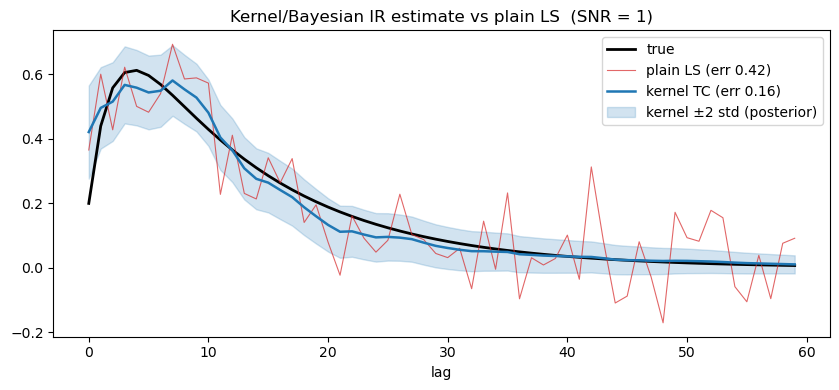

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(t, g_true, "k", lw=2, label="true")
ax.plot(t, g_ls, "C3", lw=0.8, alpha=0.7, label=f"plain LS (err {relerr(g_ls):.2f})")
ax.plot(t, g_kernel, "C0", lw=1.8, label=f"kernel TC (err {relerr(g_kernel):.2f})")
ax.fill_between(t, g_kernel - 2*g_std, g_kernel + 2*g_std, color="C0", alpha=0.2,
                label="kernel ±2 std (posterior)")
ax.set_title("Kernel/Bayesian IR estimate vs plain LS  (SNR = 1)")
ax.set_xlabel("lag"); ax.legend(); fig.tight_layout(); plt.show()

**Part 1 takeaway.** Plain LS chases the noise; the kernel estimate stays close to the truth because the stable-spline prior says "the IR decays smoothly", and the marginal likelihood sets *how much* to trust that prior from the data itself. The shaded band is genuine posterior uncertainty.

## Part 2 — the Bayesian-TIB fusion

Now use the **TIB basis** as the feature map. For a SISO grid of poles `{λ_k}`, the basis functions of the IR are the decaying modes `φ_k(t) = λ_k^t` (for distinct real poles these span the same space as the TIB mode impulse responses from `null_basis_realization`, but are numerically robust on a large dense grid). The model is `g(t) = Σ_k c_k φ_k(t)`; the output is `y = Ψ c + e` with `Ψ = Φ B_φ` (each basis mode convolved with the input).

* **Plain TIB-LS** — least-squares for `c` (what `fit_output_matrix` does). On a rich/overcomplete pole grid the near-collinear modes make this high-variance.
* **Bayesian-TIB** — the *same* `c`, but with a Gaussian prior `c ~ N(0, λ I)`, `λ`/`σ²` set by marginal likelihood: `ĉ = (Ψᵀ Ψ / σ² + I/λ)⁻¹ Ψᵀ y / σ²`. This is TIB's basis + the kernel's penalty.

P=40 poles (overcomplete)
plain TIB-LS  rel err: 0.257
Bayesian-TIB  rel err: 0.087   (lambda=0.0775, sigma^2=3.11)


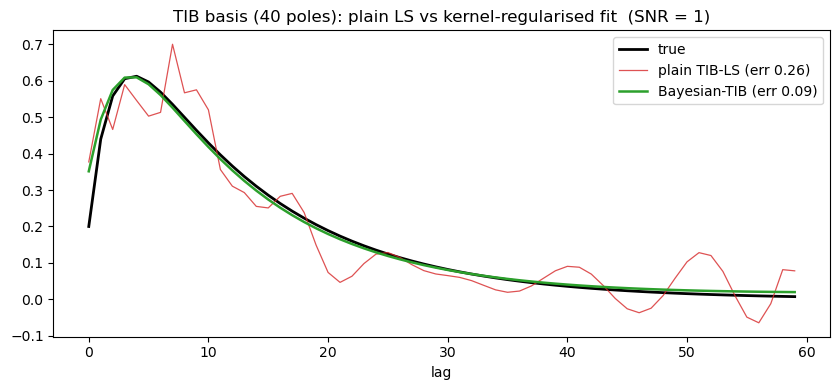

In [6]:
def tib_basis(poles, n):
    """SISO decaying-mode basis: column k is phi_k(t) = lambda_k**t, t=0..n-1.
    For distinct real poles this spans the same space as the TIB mode impulse
    responses (null_basis_realization), but is numerically robust on a large,
    dense pole grid (the Blaschke deflation product underflows for many close
    real poles)."""
    t = np.arange(n)
    return poles[None, :] ** t[:, None]      # (n, P)

def neg_lml_ridge(theta, Psi, y):
    lam, s2 = np.exp(theta[0]), np.exp(theta[1])
    Sig = lam * (Psi @ Psi.T) + s2 * np.eye(Psi.shape[0])
    L, low = cho_factor(Sig, lower=True)
    ay = cho_solve((L, low), y)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return 0.5 * (y @ ay) + 0.5 * logdet + 0.5 * len(y) * np.log(2 * np.pi)

def bayesian_tib(Psi, y):
    r = minimize(neg_lml_ridge, [0.0, np.log(np.var(y))], args=(Psi, y),
                 method="Nelder-Mead", options=dict(maxiter=2000, xatol=1e-5, fatol=1e-5))
    lam, s2 = np.exp(r.x[0]), np.exp(r.x[1])
    P = Psi.shape[1]
    c = np.linalg.solve(Psi.T @ Psi / s2 + np.eye(P) / lam, Psi.T @ y / s2)
    return c, lam, s2

P = 40                                       # overcomplete pole grid
poles = poles_chebyshev_roots(P)
Bphi = tib_basis(poles, n)
Psi = Phi @ Bphi                             # N x P

c_ls, *_ = np.linalg.lstsq(Psi, y, rcond=None)
g_tib_ls = Bphi @ c_ls

c_b, lam_b, s2_b = bayesian_tib(Psi, y)
g_tib_b = Bphi @ c_b

print(f"P={P} poles (overcomplete)")
print(f"plain TIB-LS  rel err: {relerr(g_tib_ls):.3f}")
print(f"Bayesian-TIB  rel err: {relerr(g_tib_b):.3f}   (lambda={lam_b:.3g}, sigma^2={s2_b:.3g})")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(t, g_true, "k", lw=2, label="true")
ax.plot(t, g_tib_ls, "C3", lw=0.9, alpha=0.8, label=f"plain TIB-LS (err {relerr(g_tib_ls):.2f})")
ax.plot(t, g_tib_b, "C2", lw=1.8, label=f"Bayesian-TIB (err {relerr(g_tib_b):.2f})")
ax.set_title(f"TIB basis ({P} poles): plain LS vs kernel-regularised fit  (SNR = 1)")
ax.set_xlabel("lag"); ax.legend(); fig.tight_layout(); plt.show()

### Why the prior matters: sweep the basis richness `P`

As we enlarge the pole grid, plain TIB-LS lowers bias but its variance explodes (collinear modes fit noise). Bayesian-TIB keeps a rich basis *and* controls variance via evidence-tuned shrinkage — decoupling basis richness from effective complexity.

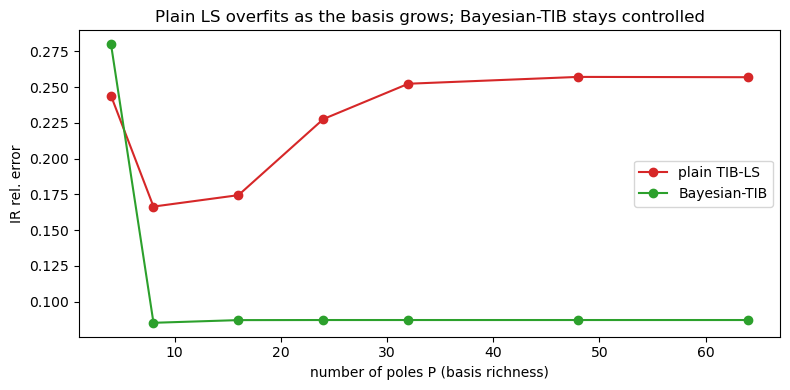

P      : [4, 8, 16, 24, 32, 48, 64]
LS  err: [0.244, 0.167, 0.175, 0.228, 0.252, 0.257, 0.257]
Bayes  : [0.28, 0.085, 0.087, 0.087, 0.087, 0.087, 0.087]


In [7]:
Ps = [4, 8, 16, 24, 32, 48, 64]
err_ls, err_b = [], []
for Pk in Ps:
    Bk = tib_basis(poles_chebyshev_roots(Pk), n)
    Psik = Phi @ Bk
    c1, *_ = np.linalg.lstsq(Psik, y, rcond=None)
    err_ls.append(relerr(Bk @ c1))
    cb, *_ = bayesian_tib(Psik, y)
    err_b.append(relerr(Bk @ cb))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Ps, err_ls, "C3-o", label="plain TIB-LS")
ax.plot(Ps, err_b, "C2-o", label="Bayesian-TIB")
ax.set_xlabel("number of poles P (basis richness)"); ax.set_ylabel("IR rel. error")
ax.set_title("Plain LS overfits as the basis grows; Bayesian-TIB stays controlled")
ax.legend(); fig.tight_layout(); plt.show()
print("P      :", Ps)
print("LS  err:", [round(e, 3) for e in err_ls])
print("Bayes  :", [round(e, 3) for e in err_b])

## Conclusions

* **Kernel/Bayesian ID** estimates the impulse response as a GP with a *stability* kernel; the marginal likelihood self-tunes the regularisation, so it is robust at low SNR and gives uncertainty bands — all in ~50 lines.
* **Bayesian-TIB** is the same idea expressed in *your* model: keep the TIB basis (poles + null vectors), but replace plain least-squares-for-`C` with a kernel-regularised fit. This lets you use a rich/overcomplete pole grid (low bias) without overfitting (controlled variance).
* This makes concrete the wiki framing: **TIB = a hard-truncated explicit basis; the kernel = a soft-weighted prior over the basis.** They are not rivals — kernel regularisation is exactly what TIB's `C`-estimation needs at low SNR.

*(SISO for clarity. The MIMO extension uses the TIB null vectors as input directions and a matrix/group prior on the residues; the realisation step is `tib_from_state_space`.)*